## Regression using e1_nutrients

#### Imports
In addition to the common libraries, sklearn, matplotlib, pandas and pathlib, I am using sklearnex which accelerates/optimises sklearn with vectorisation and GPU usage

In [ ]:
# Required imports (includes sklearnex for better performance)
import sklearnex
sklearnex.patch_sklearn()
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


#### Define filter outliers method
After displaying each nutrient per depth on a scatter graph it was possible to see grouping. After this I created a boxplot for each nutrient per depth, from this it was possible to see that outliers were outside of the interquatile range bands, so this was the filtering method I chose.

In [4]:
def filter_outliers(df, column):
    q1 = df[column].quantile(0.25) # calculate the first quartile
    q3 = df[column].quantile(0.75) # calculate the third quartile
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr # calculate the lower bound for outliers
    upper_bound = q3 + 1.5 * iqr # calculate the upper bound for outliers
    df[column] = df[column].where((df[column] >= lower_bound) & (df[column] <= upper_bound), None) # replace values outside the bounds with None
    return df

#### Import data and split test/train with 20% test size
I read the nutrients file in with pandas so that the data is as a DataFrame which is useful for later processing. Then I split the data into an 80/20 train/test split with set random_state 42 to ensure consistent results

In [5]:
# Import data and split into train/test sets
df = pd.read_csv(Path("e1_nutrients.csv"))
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42) # split the data into training and testing sets with an 80-20 split and a fixed random state for reproducibility

#### Filter outliers using IQR per depth and nutrient
For filtering, I create a copy of the train data (to display filtering in graph vs unfiltered), then loop through each set of data per Depth. Then I create a copy of the data for that depth using a filter and for each column in that depth, run the filtering method and set the filtered data back to the original. This fills train_filtered with None values where outliers were, I then use dropna to remove rows with a None value to discard any sets of reading with an outlier.

Filtering is required to avoid training the model on erroneous data which would reduce its final accuracy

Initially, I was filtering the target column NITRITE as well as the non_target columns, however this was incorrect and caused me to be chasing bad results in regression.

In [6]:
# Filter outliers using IQR for each depth and nutrient column (excluding "NITRITE" as it's the target)
non_target_columns = [col for col in train_df.columns if col != "NITRITE"]

train_filtered = train_df.copy()
for depth in train_filtered["Depth"].unique():
    mask = train_filtered["Depth"] == depth
    depth_subset = train_filtered.loc[mask].copy()
    for column in non_target_columns:
        depth_subset = filter_outliers(depth_subset, column)
    train_filtered.loc[mask] = depth_subset
train_clean = train_filtered.dropna()

#### Scale train and test using RobustScaler
After filtering and cleaning the train dataset, it is scaled using RobustScaler which scales, normalises, and centers using IQR. 2 scalers are needed, one for the input data (x axis, all columns bar NITRITE) and one for the target values (y axis, only NITRITE column).

Data must be scaled as the regressors will naturally favour higher values and have no context on the meaning of the data so will fail to learn the patterns of the data correctly

The scalers are fit on the train data only, but used to transform both the train and the test data. This ensures the regressors cannot become indirectly aware of the test data.

In [7]:
# Scale features and target using RobustScaler
x_scaler = RobustScaler()
y_scaler = RobustScaler()
x_train = x_scaler.fit_transform(train_clean.drop(columns=["NITRITE"]))
y_train = y_scaler.fit_transform(train_clean[["NITRITE"]]).ravel()
x_test = x_scaler.transform(test_df.drop(columns=["NITRITE"]))
y_test = y_scaler.transform(test_df[["NITRITE"]]).ravel()

df_filtered = train_filtered
df_scaled = train_clean.copy().astype(float)
cols_to_scale = df_scaled.columns != "NITRITE"
df_scaled.loc[:, cols_to_scale] = x_train

#### Scatter graphs to display filtering and scaling
To confirm the filtering and scaling was successful, I plotted original vs filtered vs scaled and filtered. The scaled & filtered data is using a seperate axis as it is scaled and so would not line up with the corresponding depth while on the original axis.

The graphs show that NITRITE is untouched by filtering and scaling, and that each other nutrient correctly has outliers removed and has been scaled. 

Note: x axis has an offset for each dataset to better show the difference

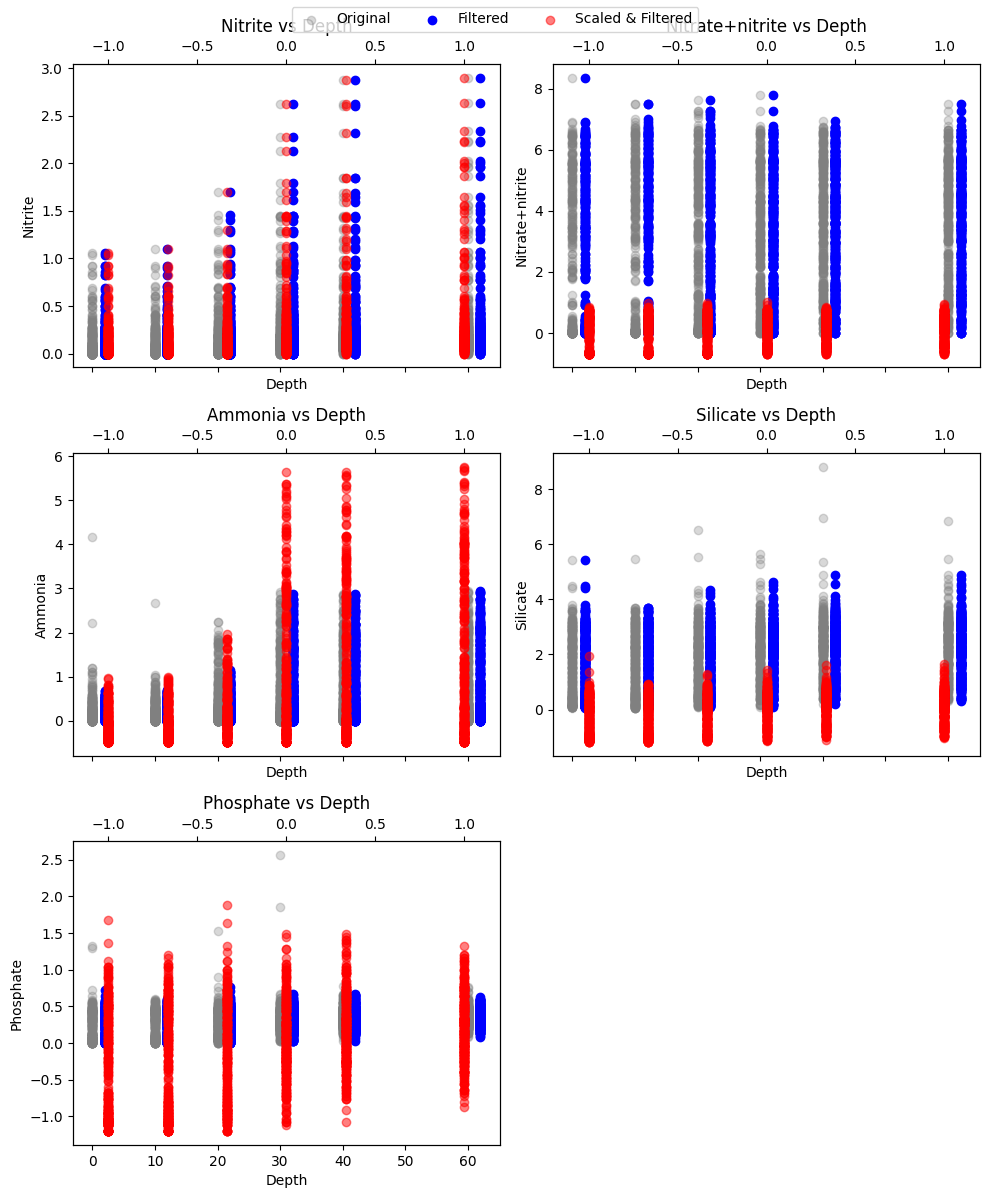

In [8]:
# Show filtering and scaling results of each chemical vs depth to ensure they are working
plot_columns = list(df.columns[1:])
fig, axes = plt.subplots(ncols=2, nrows=3, figsize=(10, 12), sharex=True)
axes = axes.flatten()

for i, column in enumerate(plot_columns):
    ax = axes[i]
    ax.scatter(train_df['Depth'], train_df[column], color="grey", alpha=0.3, label='Original')
    ax.scatter(df_filtered['Depth']+2, df_filtered[column], color="blue", label='Filtered')
    ax2 = ax.twiny()
    ax2.set_xlim(-1.2, 1.2)
    ax2.scatter(df_scaled['Depth'], df_scaled[column], color="red", alpha=0.5, label='Scaled & Filtered')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    ax.set_xlabel("Depth")
    ax.set_ylabel(column.capitalize())
    ax.set_title(f"{column.capitalize()} vs Depth")


handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles = handles1 + handles2
labels = labels1 + labels2
fig.legend(handles, labels, loc="upper center", ncol=3)
axes[-1].axis("off")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

#### RandomizedSearchCV for MLPRegressor hyperparameters
In order to tune the MLPRegressor's hyperparameters for the dataset, I am using RandomizedSearchCV with a varied parameter grid searching for the best parameter set scored on mean squared error. 

Previously I was using GridSearchCV, however, I switched to RandomizedSearch due to its faster speed as it doesn't evaluate every single option which was acceptable for my tuning. 

I ran the search many times trying many different possible parameter sets and found solutions which produced a better MSE but were much worse on cross validation due to overfitting. I continued to alter the parameter grid and removed some parameters from the grid completely such as solver and early_stopping as I found the defaults to be the best for this dataset.

Ultimately, the best parameters I found were `{'validation_fraction': 0.1, 'n_iter_no_change': 30, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (100,), 'alpha': 0.0005}`, however, there is very little improvement from the default parameters in this task.

In [ ]:
# Use randomised search to find the best hyperparameters for MLPRegressor with a validation set, then evaluate on the test set
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
mlp = MLPRegressor(max_iter=4000, random_state=42)
param_grid = [
    {
        'hidden_layer_sizes': [
            (100, 50),
            (100,),
            (100, 50, 25),
            (128, 64),
            (100, 100, 100),
        ],
        'alpha': [0.0005, 0.001],
        'learning_rate_init': [0.005, 0.001],
        'validation_fraction': [0.1],
        'n_iter_no_change': [30]
    }
]

grid_search = RandomizedSearchCV(estimator=mlp, param_distributions=param_grid, n_iter=200, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(x_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
test_preds = grid_search.best_estimator_.predict(x_test)
test_preds_unscaled = y_scaler.inverse_transform(test_preds.reshape(-1, 1)).ravel()
y_test_unscaled = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
print("MSE test (scaled):", mean_squared_error(y_test, test_preds))
print("MSE test (unscaled):", mean_squared_error(y_test_unscaled, test_preds_unscaled))
cv_results = grid_search.cv_results_
best_index = grid_search.best_index_
print(f"Best Train Score: {-cv_results['mean_train_score'][best_index]}")
print(f"Best Val Score: {-cv_results['mean_test_score'][best_index]}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/mdata/CS/comp2002/.venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 20 is smaller than n_iter=200. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END alpha=0.0005, hidden_layer_sizes=(100,), learning_rate_init=0.005, n_iter_no_change=30, validation_fraction=0.1; total time=   1.6s
[CV] END alpha=0.0005, hidden_layer_sizes=(100, 50), learning_rate_init=0.005, n_iter_no_change=30, validation_fraction=0.1; total time=   3.6s
[CV] END alpha=0.0005, hidden_layer_sizes=(100, 50), learning_rate_init=0.005, n_iter_no_change=30, validation_fraction=0.1; total time=   3.6s
[CV] END alpha=0.0005, hidden_layer_sizes=(100, 50), learning_rate_init=0.005, n_iter_no_change=30, validation_fraction=0.1; total time=   3.9s
[CV] END alpha=0.0005, hidden_layer_sizes=(100, 50), learning_rate_init=0.005, n_iter_no_change=30, validation_fraction=0.1; total time=   4.0s
[CV] END alpha=0.0005, hidden_layer_sizes=(100, 50), learning_rate_init=0.005, n_iter_no_change=30, validation_fraction=0.1; total time=   4.1s
[CV] END alpha=0.0005, hidden_layer_sizes=(100,), learning_rate_init=0.005, n_iter_no_change=30, validation_fraction=0.1; total time=   4.5

#### Find Best Hyperparams for RandomForest
Just like with MLPRegressor, I also used RandomizedSearchCV to tune the RandomForestRegressor's hyperparameters. This helped to slightly reduce overfitting of the train data, however I was unable to find much improvement just from hyperparamater tuning. 

The search works by picking a random set of parameters and applying them to the regressor and using cross validation to find the parameters which result in the lowest MSE.

I ran the search many times with a large variation of parameters and ended up removing some parameters from the grid such as `bootstrap` which I found the default to be the best option. 

Ultimately, the best paramaters I found were `'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}`

In [ ]:
# Use randomised search to find the best hyperparameters for RandomForestRegressor, then evaluate on the test set
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error

tree = RandomForestRegressor(random_state=42)
param_distributions = {
    'n_estimators': [100, 200, 500, 800, 1000],
    'max_depth': [None, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 3, 4, 6],
    'max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0],
}
grid_search_tree = RandomizedSearchCV(estimator=tree, param_distributions=param_distributions, n_iter=200, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error', return_train_score=True)
grid_search_tree.fit(x_train, y_train)
print("Best parameters found for Random Forest: ", grid_search_tree.best_params_)
test_preds_tree = grid_search_tree.best_estimator_.predict(x_test)
test_preds_tree_unscaled = y_scaler.inverse_transform(test_preds_tree.reshape(-1, 1)).ravel()

default_tree = RandomForestRegressor(random_state=42)
default_tree.fit(x_train, y_train)
default_test_preds_tree = default_tree.predict(x_test)
default_test_preds_tree_unscaled = y_scaler.inverse_transform(default_test_preds_tree.reshape(-1, 1)).ravel()
data = {
    "model": ["RandomForestRegressor-tuned", "RandomForestRegressor-default"],
    "test_scaled_mse": [mean_squared_error(y_test, test_preds_tree), mean_squared_error(y_test, default_test_preds_tree)],
    "test_unscaled_mse": [mean_squared_error(y_test_unscaled, test_preds_tree_unscaled), mean_squared_error(y_test_unscaled, default_test_preds_tree_unscaled)]
}
results_df = pd.DataFrame(data)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV] END max_depth=25, max_features=0.7, min_samples_leaf=2, min_samples_split=10, n_estimators=1000; total time=   0.7s
[CV] END max_depth=15, max_features=1.0, min_samples_leaf=6, min_samples_split=5, n_estimators=1000; total time=   0.8s
[CV] END max_depth=15, max_features=1.0, min_samples_leaf=3, min_samples_split=2, n_estimators=800; total time=   1.0s
[CV] END max_depth=15, max_features=1.0, min_samples_leaf=6, min_samples_split=5, n_estimators=1000; total time=   0.9s
[CV] END max_depth=25, max_features=0.7, min_samples_leaf=2, min_samples_split=10, n_estimators=1000; total time=   0.8s
[CV] END max_depth=25, max_features=0.7, min_samples_leaf=2, min_samples_split=10, n_estimators=1000; total time=   0.8s
[CV] END max_depth=15, max_features=1.0, min_samples_leaf=3, min_samples_split=2, n_estimators=800; total time=   1.0s
[CV] END max_depth=15, max_features=1.0, min_samples_leaf=3, min_samples_split=2, n_estimators=

#### Regressions

Each regressor is added to a list and evaluated with the test and train data to produce MSE, cross validation and R2 scores.

Commented out is functionality I added which produces an unscaled MSE which I used when comparing scalers to find the most optimimum scaler. This was needed as some scalers outputted a different range and therefore produced MSEs in a different range and were incomparable.

1. RandomForest default settings
2. RandomForest tuned with more estimators, and additional parameters from search
3. Linear regression
4. MLPRegressor default settings (increased max iterations)
5. MLPRegressor tuned with hyperparameters found from search

#### Outputs

1. R2 Test and Train
2. MSE Test and Train
3. Cross validation 

In [9]:
# Run regression models and compare results
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score

regressors = []
regressors.append(("RandomForestRegressor-default", RandomForestRegressor(random_state=42)))
regressors.append(("RF-Tuned", RandomForestRegressor(
    max_depth=30,
    max_features='log2',
    n_estimators=800, 
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
)))
regressors.append(("LinearRegression-default", LinearRegression()))
regressors.append(("MLPRegressor-default", MLPRegressor(random_state=42, max_iter=2000)))
# params from grid search with best cv mse
regressors.append(("MLPRegressor-tuned1", MLPRegressor(n_iter_no_change=30, max_iter=4000, hidden_layer_sizes=(100,), random_state=42, alpha=0.0005, learning_rate_init=0.001, validation_fraction=0.1)))


scores = []

for regressor_name, regressor in regressors:
    regressor.fit(x_train, y_train)
    train_preds = regressor.predict(x_train)
    test_preds = regressor.predict(x_test)
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    #test_preds_unscaled = y_scaler.inverse_transform(test_preds.reshape(-1, 1)).ravel()
    #y_test_unscaled = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
    #train_preds_unscaled = y_scaler.inverse_transform(train_preds.reshape(-1, 1)).ravel()
    #y_train_unscaled = y_scaler.inverse_transform(y_train.reshape(-1, 1)).ravel()

    test_scaled_mse = mean_squared_error(y_test, test_preds)
    #test_unscaled_mse = mean_squared_error(y_test_unscaled, test_preds_unscaled)

    train_scaled_mse = mean_squared_error(y_train, train_preds)
    #train_unscaled_mse = mean_squared_error(y_train_unscaled, train_preds_unscaled)

    cross_val = cross_val_score(regressor, x_train, y_train, cv=5, scoring='neg_mean_squared_error')

    scores.append((regressor_name, train_r2, test_r2, train_scaled_mse, test_scaled_mse, cross_val.mean(), cross_val.std())) #, train_unscaled_mse, test_unscaled_mse,

pd.DataFrame(scores, columns=["model", "train_r2", "test_r2", "train_scaled_mse", "test_scaled_mse", "cross_val_mean", "cross_val_std"]).sort_values("test_scaled_mse") # "train_unscaled_mse", "test_unscaled_mse", 

,model,train_r2,test_r2,train_scaled_mse,test_scaled_mse,cross_val_mean,cross_val_std
1,RF-Tuned,0.929991,0.562600,0.215710,1.197370,-1.616232,0.196466
0,RandomForestRegressor-default,0.930312,0.543669,0.214721,1.249192,-1.700626,0.156451
4,MLPRegressor-tuned1,0.572500,0.373311,1.317196,1.715541,-1.899782,0.169191
3,MLPRegressor-default,0.458773,0.336798,1.667608,1.815494,-1.905816,0.124032
2,LinearRegression-default,0.136676,0.089373,2.660041,2.492813,-2.672020,0.326600


#### Plot feature importance for random forest tuned regressor
To evaluate the performance of the tuned random forest regressor, I have plotted the feature importance for predicting nitrite. The graph shows that the most important feature found by the tree was the NITRATE+NITRITE feature which suggests the model may be too heavily relying on this value due to it being the sum of the target column and another data point. 

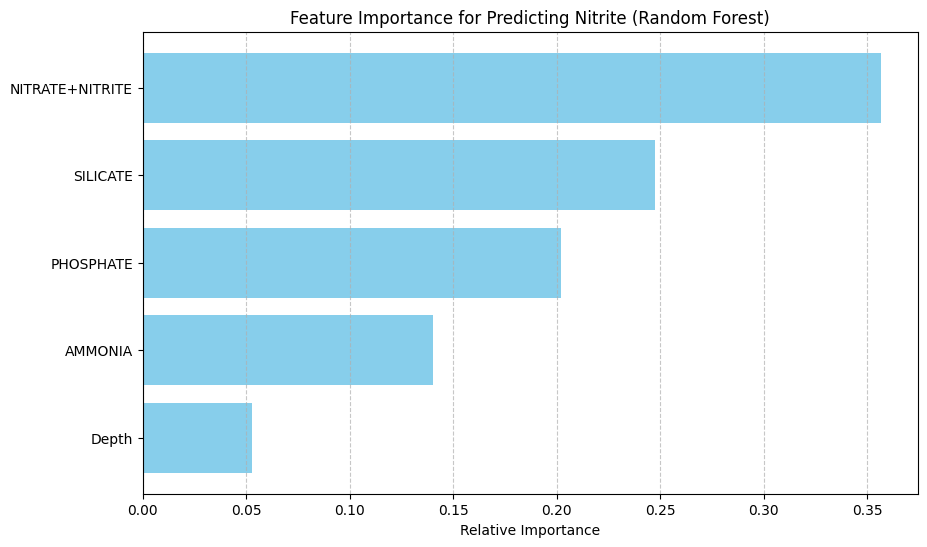

In [78]:
import numpy as np
feature_names = train_clean.drop(columns=["NITRITE"]).columns

rf_default = regressors[0][1]
importances = rf_default.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title("Feature Importance for Predicting Nitrite (Random Forest)")
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### Plot MSE per regressor
To finally evaluate the performance of each regressor on the dataset, I plot the MSE and Cross Val Mean of each regressor.

Looking at only MSE, it would appear that the tuned random forest model is the best for the dataset, however taking cross validation standard deviation into account, it is possible to see the model does not perform as well on all data and the default random forest model may be preferable as it is the second best for MSE and is more consistent than the tuned version. 

Interestingly, the tuned MLP regressor is also less consistent in cross validation than the default parameter model despite a slightly higher MSE. This shows that simply optimising for just MSE does not always produce a better model

The random forest models are significantly overfitting the data (shown by very high train R2 but low test R2). The tuned random forest generalised better than the default one achieving a better test MSE and better cross validation mean. This happened due to limiting the tree to less features ('log2' vs default) and increasing the number of estimators (100 -> 800) which helps to average out more noise.

The neural networks performed worse than the tree models but the tuned model had a great increase from the default model. This is due the early stopping set by the validation_fraction and n_iter_no_change which stopped the training when generalisation began to fall. 


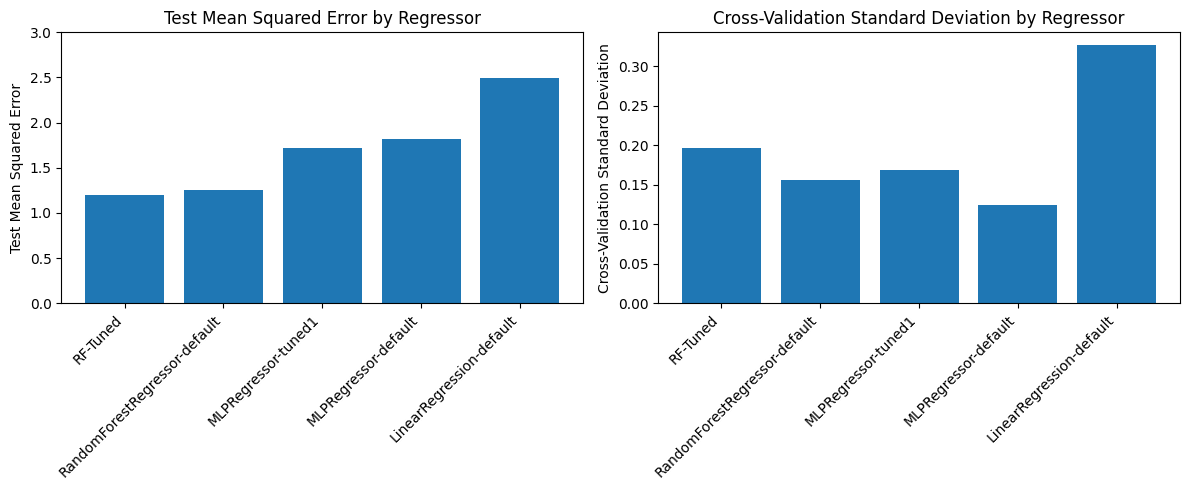

In [88]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
scores = sorted(scores, key=lambda x: x[4])  # Sort by test_unscaled_mse
regressor_names = [score[0] for score in scores]
cross_val_stds = [score[6] for score in scores]
ms_values = [score[4] for score in scores]

ax1.bar(range(len(regressor_names)), ms_values)
ax1.set_xticks(range(len(regressor_names)))
ax1.set_xticklabels(regressor_names, rotation=45, ha='right')
ax1.set_ylabel('Test Mean Squared Error')
ax1.set_title('Test Mean Squared Error by Regressor')
ax1.set_ylim(0, 3)

ax2.bar(range(len(regressor_names)), cross_val_stds)
ax2.set_xticks(range(len(regressor_names)))
ax2.set_xticklabels(regressor_names, rotation=45, ha='right')
ax2.set_ylabel('Cross-Validation Standard Deviation')
ax2.set_title('Cross-Validation Standard Deviation by Regressor')

plt.tight_layout()
plt.show()

# Optimisation of problem using 3 algorithms

#### Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import sin

#### Define problem (McCormick function)


In [2]:
problem = lambda x, y: np.sin(x+y) + np.power(x-y, 2) - 1.5*x + 2.5*y + 1

#### Generate 500 random solutions and plot fitness
First, we will generate 500 random solutions uniformly in the range -5 to 5 as suggested as a starting point. Then I calculate the fitness for each of the 500 solutions and plot the solutions vs the fitness on a scatter graph

In [3]:
# Generate 500 random solutions in the range [-5, 5]
x = np.random.uniform(-5, 5, 500)
y = np.random.uniform(-5, 5, 500)
fitness = np.array([(x,y,problem(x, y)) for x, y in zip(x, y)])

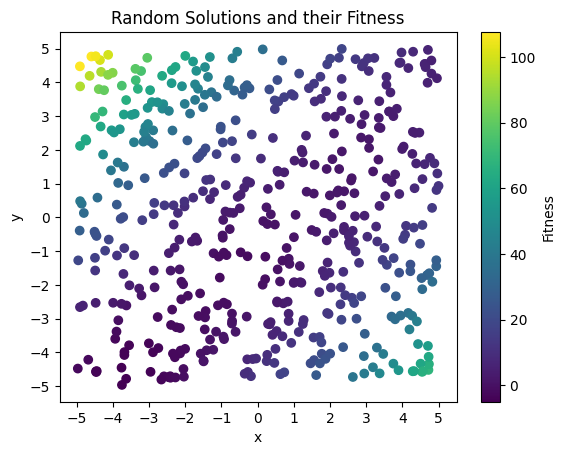

In [4]:
plt.scatter(x, y, c=fitness[:, 2], cmap='viridis') # Visualise the solutions and their fitnesses
plt.xticks(np.arange(-5, 6, 1))
plt.yticks(np.arange(-5, 6, 1))
plt.colorbar(label='Fitness')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Random Solutions and their Fitness')
plt.show()

After plotting the 500 random solutions it becomes clear there is a valley of best fitnesses in a diagonal line across the graph. By selecting and replotting the top 100 solutions (by fitness), it is possible to define a smaller search range for the hillclimber and evolutionary algorithms to start at. 

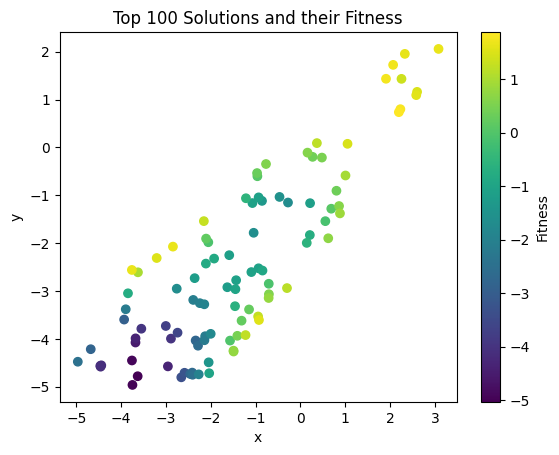

In [5]:
top_100_fitness = fitness[np.argsort(fitness[:, 2])[:100]] # Select the top 100 solutions based on fitness
plt.scatter(top_100_fitness[:, 0], top_100_fitness[:, 1], c=top_100_fitness[:, 2], cmap='viridis')
plt.colorbar(label='Fitness')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Top 100 Solutions and their Fitness')
plt.show()

In [6]:
new_x_min, new_x_max = top_100_fitness[:, 0].min(), top_100_fitness[:, 0].max() # Return the x and y ranges of the top 100 solutions, and the best solution from random sampling
new_y_min, new_y_max = top_100_fitness[:, 1].min(), top_100_fitness[:, 1].max()
best_x_from_random, best_y_from_random, best_fitness = top_100_fitness[0]
print(f"Best solution from random sampling: x={best_x_from_random:.2f}, y={best_y_from_random:.2f}, fitness={best_fitness:.2f}")
pd.DataFrame(
    {"min": [new_x_min, new_y_min], "max": [new_x_max, new_y_max]},
    index=["X", "Y"],
)

Best solution from random sampling: x=-3.63, y=-4.78, fitness=-5.03


,min,max
X,-4.964905,3.078748
Y,-4.962272,2.058598


#### Define hillclimber algorithm using guassian mutation
The hillclimber function accepts an initial starting point, number of iterations, the problem and the mutation function.

I am using guassian mutation as a lambda which works by performing a random mutation from a normal distribution centered around 0 to the input.

The function starts by setting initial points as the best_x and best_y and evaluating initial fitness. Then for each iteration it applies a random mutation to x and y, recalculates the fitness, stores the solution and if the fitness is higher, it sets best_x, best_y and current fitness to the new solution.

After all iterations have completed, the best solution and all solutions are returned.

To help with evaluating the algorithm, I have defined a helper function evaluate_hill_climber which simplifies running the algorithm repeatedly to evaluate the reliability.

The visualise function produces 3 graphs:
1. Solutions vs fitness (Shows how the algorithm moves towards the best solution and creates a grouping around it)
2. Fitness vs iterations (Shows how the solution improves every iteration, and shows the ideal stopping point)
3. Final best fitness per 100 runs (Shows the reliability of algorithm, only shown when data is from multiple runs) 

In [7]:
gmutate = lambda x: x + np.random.normal(0, 0.1) # Mutates x by random value from normal distribution around 0 with scale of 0.1

In [8]:
def hillclimb(x: float, y: float, fitness_func: callable, iterations: int) -> tuple[float, float, float, np.ndarray]: # Perform the hill climbing algorithm starting from (x, y) for a given number of iterations, using the provided fitness function
    best_x, best_y = x, y # Start with the initial solution
    current_fitness = fitness_func(best_x, best_y) # Evaluate the fitness of the initial solution
    solutions = np.array([[best_x, best_y, current_fitness]])
    for _ in range(iterations): # For each iteration, mutate the current solution and evaluate the new fitness
        new_x = gmutate(best_x)
        new_y = gmutate(best_y)
        new_fitness = fitness_func(new_x, new_y)
        solutions = np.append(solutions, [[new_x, new_y, new_fitness]], axis=0) # Store the new solution and its fitness

        if new_fitness < current_fitness: # If the new solution is better, update the best solution and fitness
            best_x, best_y, current_fitness = new_x, new_y, new_fitness

    return best_x, best_y, current_fitness, solutions # Return the best solution and its fitness, along with all solutions evaluated

In [9]:
def evaluate_hill_climber(iterations: int, fitness_func: callable, runs: int = 1, x_range: tuple = (-5, 5), y_range: tuple = (-5, 5)) -> tuple[float, float, float, np.ndarray, list]:
    fitnesses = []
    for i in range(runs):
        init_x, init_y = np.random.uniform(x_range[0], x_range[1]), np.random.uniform(y_range[0], y_range[1])
        best_x, best_y, best_fitness, solutions = hillclimb(init_x, init_y, fitness_func, iterations)
        fitnesses.append((i, best_fitness))
    return best_x, best_y, best_fitness, solutions, fitnesses

In [10]:
def visualise_hill_climbing_results(solutions: np.ndarray, fitnesses: list, is_multiple_runs: bool = False) -> tuple[plt.Figure, np.ndarray]:
    unique_fitnesses, counts = np.unique([np.round(f[1],1) for f in fitnesses], return_counts=True)
    fig, axs = plt.subplots(3 if is_multiple_runs else 2, 1, figsize=(5, 8) if is_multiple_runs else (5, 6))
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5)
    axs[0].scatter(solutions[:, 0], solutions[:, 1], c=solutions[:, 2], cmap="viridis")
    fig.colorbar(axs[0].collections[0], label="Fitness")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("y")
    axs[0].set_title("Hill Climbing Solutions and their Fitness")

    axs[1].plot(solutions[:, 2])
    axs[1].set_xlabel("Iteration")
    axs[1].set_ylabel("Fitness")
    axs[1].set_title("Fitness over Iterations")
    if is_multiple_runs:
        axs[2].set_xlabel("Run")
        axs[2].set_ylabel("Best Fitness")
        axs[2].set_title("Best Fitness across Multiple Runs of the Hill Climbing Algorithm")
        axs[2].scatter([x[0] for x in fitnesses], [x[1] for x in fitnesses])
        for f, count in zip(unique_fitnesses, counts):
            axs[2].text(100, f, f"      {count} runs", va="center")
        axs[2].set_ylim(-6, 6)
    return fig, axs

#### Run hillclimber and plot fitness per solution and over time
To run hillclimber, I select a random start x and y from a uniform distribution between -5 and 5. Hillclimber is then ran with 200 iterations to find the best solution.

On one run, the output is `Best solution: x=-0.5765798874513859, y=-1.542185000635579, fitness=-1.9117840051283141`, and that the fitness is stable after approximately 120 iterations. 

This solution (-0.5423, -1.548, fitness -1.913) is very close to the global minimum for the function (-0.54719, -1.54719, fitness -1.9133) when evaluated on the standard search space (x -1.5 to 4, y -3 to 4), however, on the expanded search space we are using here (-5, 5), it is not the global minimum. 

This shows that the hillclimber is getting stuck in a local optima.

Testing larger number of iterations (up to 20,000) shows that the algorithm does not recover from being stuck in the local optima (likely due to the low mutation making it unable to climb from a local optima found from the initial x and y).

Best solution: x=2.5958812737056176, y=1.5810140728337436, fitness=1.2286518572519758


/tmp/ipykernel_319605/1866241085.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


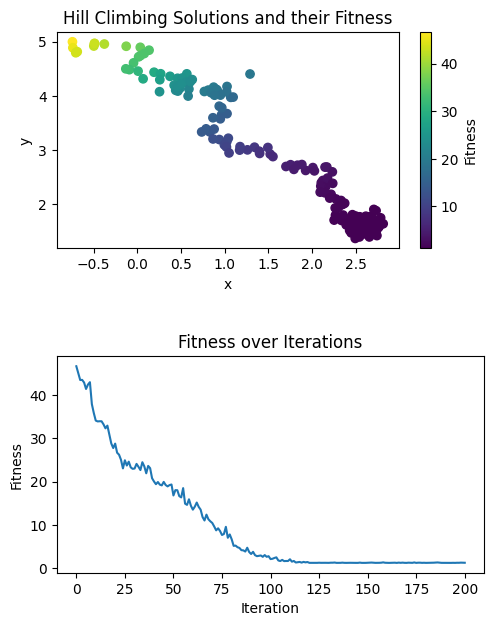

In [11]:
# Run hill climbing once inside the wide search space
best_x, best_y, best_fitness, solutions, fitnesses = evaluate_hill_climber(iterations=200, fitness_func=problem, runs=1, x_range=(-5, 5), y_range=(-5, 5))
print(f"Best solution: x={best_x}, y={best_y}, fitness={best_fitness}")
fig, axs = visualise_hill_climbing_results(solutions, fitnesses, is_multiple_runs=False)
fig.show()

#### Evaluate reliability / reproducability of hillclimber
To evaluate the algorithm, I am running it 100 times to produce a graph displaying the final best fitness for each run.

This shows that the hillclimber algorithm when run in the wide search space (-5,5), only finds the global optimum 18/100 runs. This is due to it getting stuck in local optimas very commonly and being unable to climb from them.

/tmp/ipykernel_319605/2209007856.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


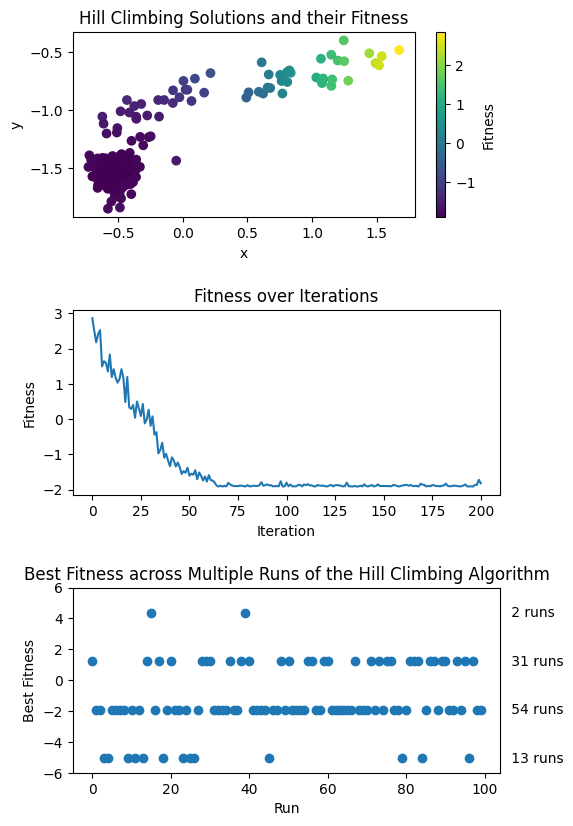

In [12]:
# Run hill climbing 100 times with random initial solutions in the wide search space, and visualise the results
best_x, best_y, best_fitness, solutions, fitnesses = evaluate_hill_climber(iterations=200, fitness_func=problem, runs=100)
fig, axs = visualise_hill_climbing_results(solutions, fitnesses, is_multiple_runs=True)
fig.show()

#### Evaluate hillclimber inside a limited search space
Instead of using the wide search space, if we instead start the search in a much smaller space (taken from the top 100 of the 500 random solutions), then the algorithm is able to find the global optimum solution 30/100 runs. 

This shows that the hillclimber algorithm benefits greatly from a tighter start solution

/tmp/ipykernel_319605/993635154.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


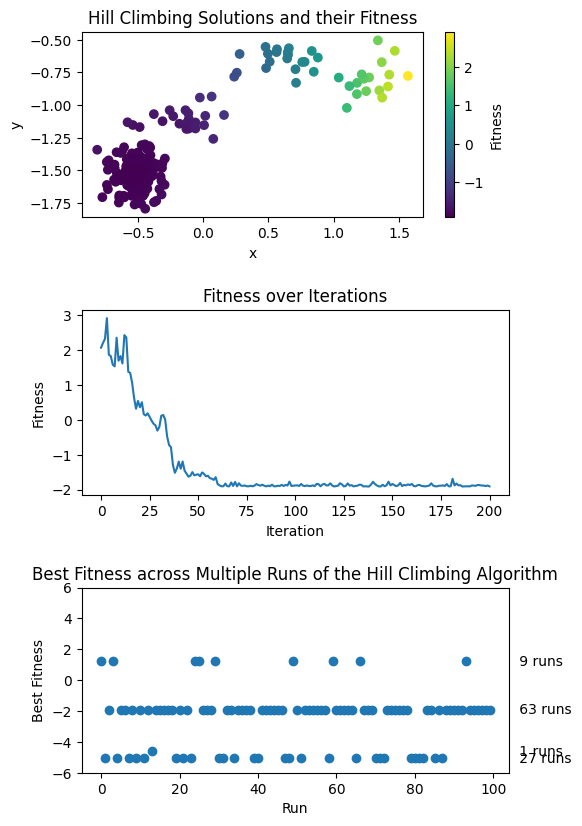

In [13]:
best_x, best_y, best_fitness, solutions, fitnesses = evaluate_hill_climber(iterations=200, fitness_func=problem, runs=100, x_range=(new_x_min, new_x_max), y_range=(new_y_min, new_y_max))
fig, axs = visualise_hill_climbing_results(solutions, fitnesses, is_multiple_runs=True)
fig.show()

#### Define evolutionary algorithm
First, I define mutate_and_eval, a helper function which will mutate the input values and evaluate the new values returning new_x, new_y, and new_fitness.

The evolutionary algorithm works by generating a population of `pop_size` with solutions uniformally distributed between -5 and 5, then fitness is calculated for each member. For each generation, each member is mutated, evaluated and added to the population. Then the population is pruned removing the bottom `pop_size` elements, and the best fitness per generation is stored.

Finally, the best solution overall is recorded and all results are returned.


In [14]:
def mutate_and_eval(x: float, y: float, fitness_func: callable) -> tuple: # Mutate x and y, then evaluate fitness
    new_x = gmutate(x)
    new_y = gmutate(y)
    new_fitness = fitness_func(new_x, new_y)
    return new_x, new_y, new_fitness

In [15]:
def evolutionary_algorithm(pop_size: int, generations: int, fitness_func: callable, x_search_range: tuple = (-5, 5), y_search_range: tuple = (-5, 5)) -> tuple: # Evolutionary algorithm with given population size and number of generations
    pop = np.random.uniform((x_search_range[0], y_search_range[0]), (x_search_range[1], y_search_range[1]), (pop_size, 2)) # Initialise population with random solutions in the given search range
    fitness = fitness_func(pop[:, 0], pop[:, 1]).reshape(-1, 1) # Evaluate fitness of initial population and flatten array
    population = np.hstack((pop, fitness))
    best_fitness_per_gen = np.array([np.min(population[:, 2])]) 
    for _ in range(generations):
        children = np.array([mutate_and_eval(x, y, fitness_func) for x, y, _ in population]) # mutate each parent to create child and evaluate fitness
        population = np.vstack((population, children)) # combine parents and children
        population = population[np.argsort(population[:, 2])][:pop_size] # select top pop_size elements
        best_fitness_per_gen = np.append(best_fitness_per_gen, population[0, 2]) 
    best_solution = population[0]
    return best_solution[0], best_solution[1], best_solution[2], population, best_fitness_per_gen

In [16]:
def visualise_evolutionary_results(solutions: np.ndarray, best_fitness_per_gen: np.ndarray) -> tuple[plt.Figure, np.ndarray]: # Visualise the results of the evolutionary algorithm, showing the solutions and their fitnesses, and the best fitness over generations
    fig, axs = plt.subplots(2)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5)
    axs[0].scatter(solutions[:, 0], solutions[:, 1], c=solutions[:, 2], cmap='viridis')
    fig.colorbar(axs[0].collections[0], label='Fitness')
    axs[0].set_xlabel('x')
    axs[0].set_ylabel('y')
    axs[0].set_title('Evolutionary Algorithm Solutions and their Fitness')
    axs[1].plot(best_fitness_per_gen)
    axs[1].set_xlabel('Generation')
    axs[1].set_ylabel('Best Fitness')
    axs[1].set_title('Best Fitness over Generations')
    axs[1].set_xticks(np.arange(0, len(best_fitness_per_gen)+1, 5))
    return fig, axs

#### Run evolutionary algorithm using 20 generations of 70 children
Running the evolutionary algorithm with 20 generations of 70 children finds the global minimum for our large search space (-5 to 5), which the hillclimber did not. This is due to the evolutionary algorithm having a large population spread which makes it much more resilient to local optimas. 

The choice of 20 generations with a population size of 70 was found by plotting fitness over generations for a set population size and reducing generations closer to the stagnant point. The algorithm was then run 100 times with the same parameters to plot the stability. 

Using a smaller population and number of generations still finds the correct answer, however, when ran 100 times it is possible to see that it gets caught in a local optima in a large percentage of runs. 

By tuning both the generation count and population size, I found that 20 generations of 70 children was a good choice as it only got stuck in a local optima in ~10/500 runs. It would be possible to increase generations and population size to reduce this even further, however, this would increase execution time so it is a trade off between performance and accuracy / stability

Best solution: x=-3.6846823598896603, y=-4.691733358566177, fitness=-5.0547653044728325


/tmp/ipykernel_319605/1548239502.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


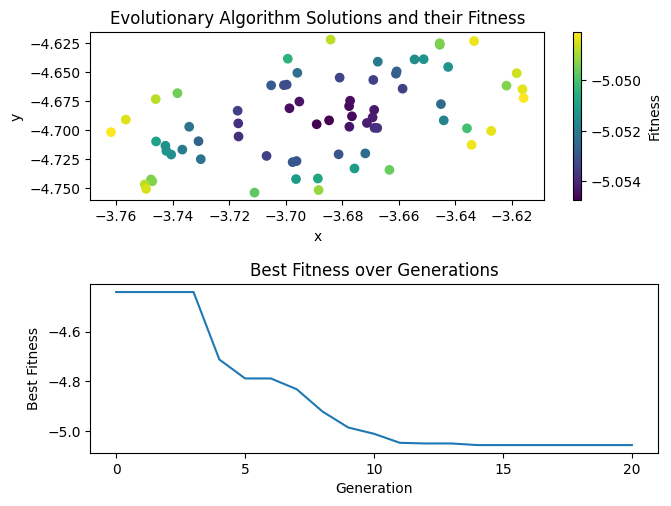

In [17]:
best_x, best_y, best_fitness, solutions, best_fitness_per_gen = evolutionary_algorithm(70, 20, problem, x_search_range=(-5, 5), y_search_range=(-5, 5))
print(f"Best solution: x={best_x}, y={best_y}, fitness={best_fitness}")
fig, axs = visualise_evolutionary_results(solutions, best_fitness_per_gen)
fig.show()

Best solution: x=-3.6925629339336234, y=-4.684104579952954, fitness=-5.054743703891903


/tmp/ipykernel_319605/2630312020.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


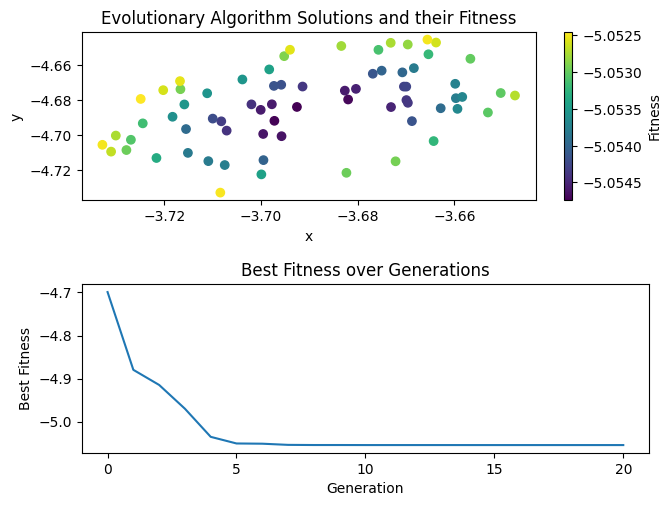

In [18]:
best_x, best_y, best_fitness, solutions, best_fitness_per_gen = evolutionary_algorithm(70, 20, problem, x_search_range=(new_x_min, new_x_max), y_search_range=(new_y_min, new_y_max))
print(f"Best solution: x={best_x}, y={best_y}, fitness={best_fitness}")
fig, axs = visualise_evolutionary_results(solutions, best_fitness_per_gen)
fig.show()

#### Run evolutionary algorithm 500 times to evaluate stability

By running the evolutionary algorithm 500 times with the same population and generation size (once within wide search space, and once within the limited space), we can see the reliability of the algorithm. 

When run in the wide search space, the algorithm finds the global optima ~490/500 times, which means it is very reproducible and is very good at solving the McCormick function. 

When run in the limited search space, the algorithm finds the global optima in less generations and finds the optima in ~499/500 times, which is a good improvement over the wide search space. This would be useful if the results are needed to be very reproducible, however it requires the testing of 500 random samples before, which will increase overall complexity and computation time. 

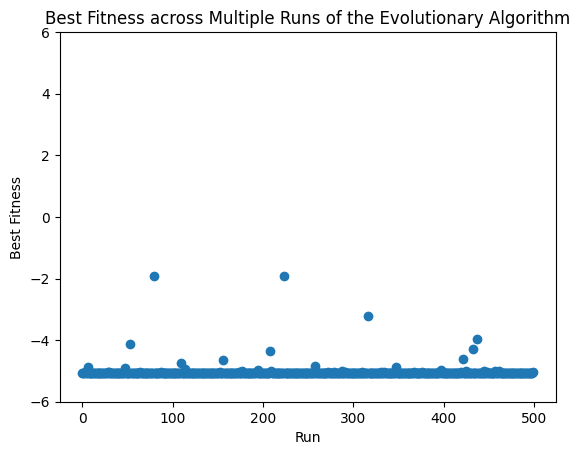

In [22]:
fitnesses = []
for i in range(500):
    best_x, best_y, best_fitness, solutions, best_fitness_per_gen = evolutionary_algorithm(70, 20, problem, x_search_range=(-5, 5), y_search_range=(-5, 5))
    fitnesses.append((i, best_fitness))
plt.scatter([x[0] for x in fitnesses], [x[1] for x in fitnesses])
plt.ylim(-6, 6)
plt.xlabel('Run')
plt.ylabel('Best Fitness')
plt.title('Best Fitness across Multiple Runs of the Evolutionary Algorithm')
plt.show()

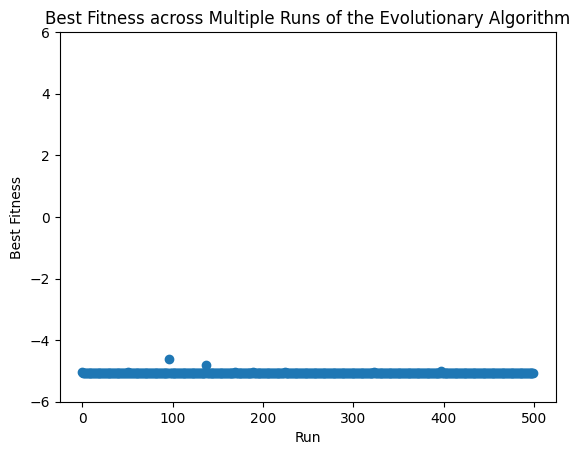

In [20]:
fitnesses = []
for i in range(500):
    best_x, best_y, best_fitness, solutions, best_fitness_per_gen = evolutionary_algorithm(70, 20, problem, x_search_range=(new_x_min, new_x_max), y_search_range=(new_y_min, new_y_max))
    fitnesses.append((i, best_fitness))
plt.scatter([x[0] for x in fitnesses], [x[1] for x in fitnesses])
plt.ylim(-6, 6)
plt.xlabel('Run')
plt.ylabel('Best Fitness')
plt.title('Best Fitness across Multiple Runs of the Evolutionary Algorithm')
plt.show()

In summary,

The hillclimber algorithm is very fast and does find an optimum in the whole search space, however, it very often gets stuck in a local optimum and only correctly finds the global optimum in the wide search space on approximately 20% of runs. This algorithm would be useful if finding the global optimum is not strictly necessary, and would benefit greatly from being given a more limited search space (as shown by the result of running in the space of the top 100 solutions from the random generations).

The evolutionary algorithm finds the global optimum very quickly, often stablising at 12 generations. It correctly finds the global optimum in the search space 98% of runs when in the wide search space. It is better at escaping local optimums due to the high spread of initial population over the search space. In the limited search space from the top 100 of 500 random generations, it becomes even more reliable with only 1/500 runs producing a very slightly suboptimal result. 

Overall, this shows hillclimber is very dependent on the initial random start and converges quickly, whereas the evolutionary algorithm takes longer to converge but isn't dependent on a single start value due to its significantly more diverse population. 

I would use the evolutionary algorithm with the wide search space as the best overall solution as it produces a very reproducible result and does not prerequire the testing of 500 random solutions (as needed for using in a limited search space).